In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
df = pd.read_csv("student_performance.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Student_ID,Name,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score
0,1,Aarav,Male,20,3.5,88,78,82.0,75
1,2,Ananya,Female,19,5.0,94,91,89.0,92
2,3,Rohan,Male,21,2.0,72,65,70.0,68
3,4,Priya,Female,20,4.5,91,84,88.0,86
4,5,Vivek,Male,22,1.5,65,58,NaN,60


In [9]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Rows and Columns: (51, 9)

Column Names:
['Student_ID', 'Name', 'Gender', 'Age', 'Study_Hours', 'Attendance', 'Math_Score', 'Science_Score', 'English_Score']

Data Types:
Student_ID         int64
Name                 str
Gender               str
Age                int64
Study_Hours      float64
Attendance         int64
Math_Score         int64
Science_Score    float64
English_Score      int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     51 non-null     int64  
 1   Name           51 non-null     str    
 2   Gender         51 non-null     str    
 3   Age            51 non-null     int64  
 4   Study_Hours    50 non-null     float64
 5   Attendance     51 non-null     int64  
 6   Math_Score     51 non-null     int64  
 7   Science_Score  50 non-null     float64
 8   English_Score  51 non-null     i

In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      1
Attendance       0
Math_Score       0
Science_Score    1
English_Score    0
dtype: int64


In [11]:
numeric_columns = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_ID       0
Name             0
Gender           0
Age              0
Study_Hours      0
Attendance       0
Math_Score       0
Science_Score    0
English_Score    0
dtype: int64


In [12]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 1


In [13]:
df = df.drop_duplicates()

df = df.reset_index(drop=True)

print("Duplicate records after removal:", df.duplicated().sum())

Duplicate records after removal: 0


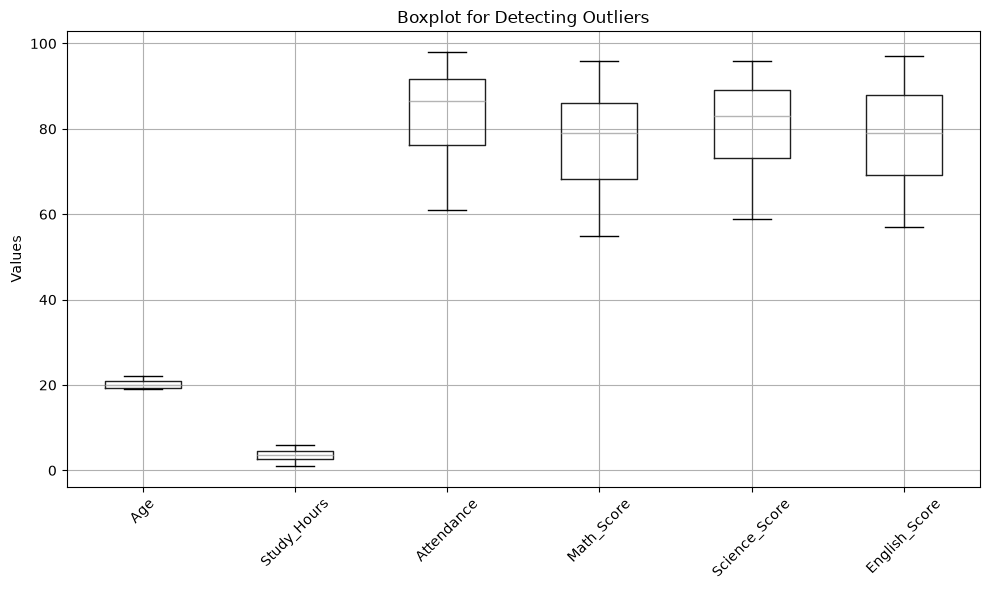

In [14]:
plt.figure(figsize=(10, 6))

df[numeric_columns].boxplot()

plt.title("Boxplot for Detecting Outliers")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.tight_layout()
plt.show()

In [15]:
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "outliers:", len(outliers))

Age outliers: 0
Study_Hours outliers: 0
Attendance outliers: 0
Math_Score outliers: 0
Science_Score outliers: 0
English_Score outliers: 0


In [16]:
print(df["Gender"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [17]:
label_encoder = LabelEncoder()

df["Gender_Encoded"] = label_encoder.fit_transform(df["Gender"])

df[["Gender", "Gender_Encoded"]].head()

,Gender,Gender_Encoded
0,Male,1
1,Female,0
2,Male,1
3,Female,0
4,Male,1


In [18]:
df = df.drop(columns=["Gender"])

In [19]:
features_to_scale = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Math_Score",
    "Science_Score",
    "English_Score"
]

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[features_to_scale] = scaler.fit_transform(
    df_scaled[features_to_scale]
)

df_scaled.head()

,Student_ID,Name,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Gender_Encoded
0,1,Aarav,-0.279776,-0.158671,0.443502,0.063012,0.117097,-0.312288,1
1,2,Ananya,-1.278977,1.002334,1.045542,1.233234,0.811743,1.204541,0
2,3,Rohan,0.719425,-1.319675,-1.161936,-1.107210,-1.073723,-0.936865,1
3,4,Priya,-0.279776,0.615332,0.744522,0.603114,0.712508,0.669190,0
4,5,Vivek,1.718626,-1.706676,-1.864316,-1.737329,0.216332,-1.650668,1


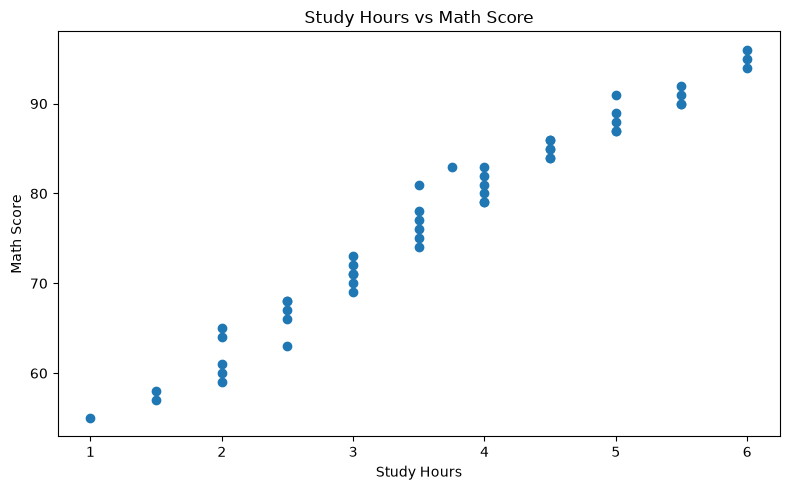

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Math_Score"])

plt.title("Study Hours vs Math Score")
plt.xlabel("Study Hours")
plt.ylabel("Math Score")

plt.tight_layout()
plt.show()

In [21]:
correlation = df.corr(numeric_only=True)

print(correlation.round(2))

                Student_ID   Age  Study_Hours  Attendance  Math_Score  \
Student_ID            1.00  0.02         0.05        0.03        0.01   
Age                   0.02  1.00        -0.60       -0.60       -0.61   
Study_Hours           0.05 -0.60         1.00        0.97        0.98   
Attendance            0.03 -0.60         0.97        1.00        0.99   
Math_Score            0.01 -0.61         0.98        0.99        1.00   
Science_Score        -0.01 -0.55         0.93        0.95        0.95   
English_Score         0.06 -0.62         0.97        0.98        0.99   
Gender_Encoded       -0.03  0.40        -0.78       -0.80       -0.81   

                Science_Score  English_Score  Gender_Encoded  
Student_ID              -0.01           0.06           -0.03  
Age                     -0.55          -0.62            0.40  
Study_Hours              0.93           0.97           -0.78  
Attendance               0.95           0.98           -0.80  
Math_Score               0.

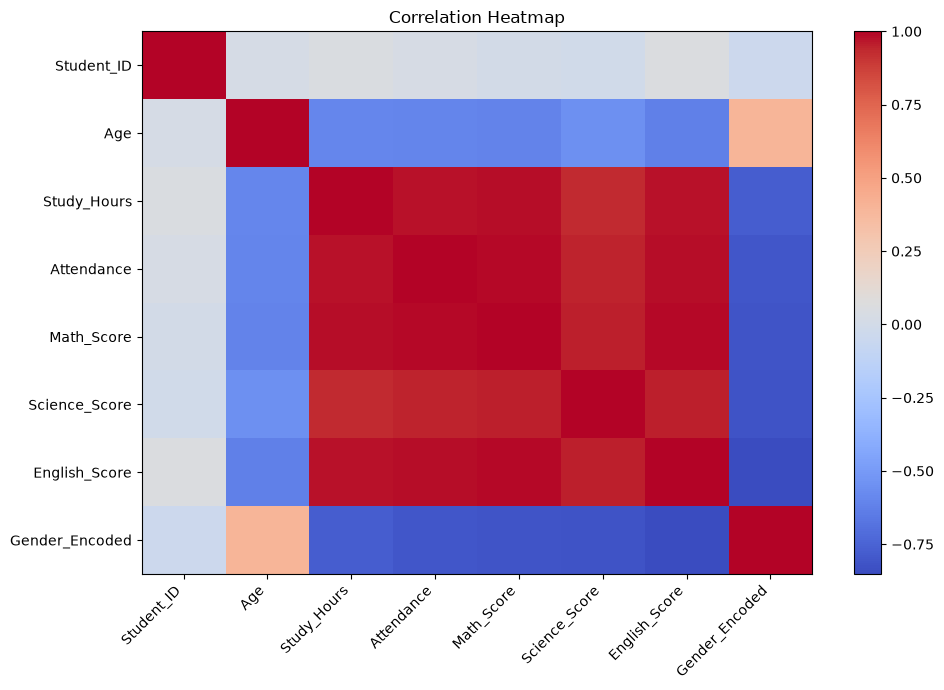

In [22]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

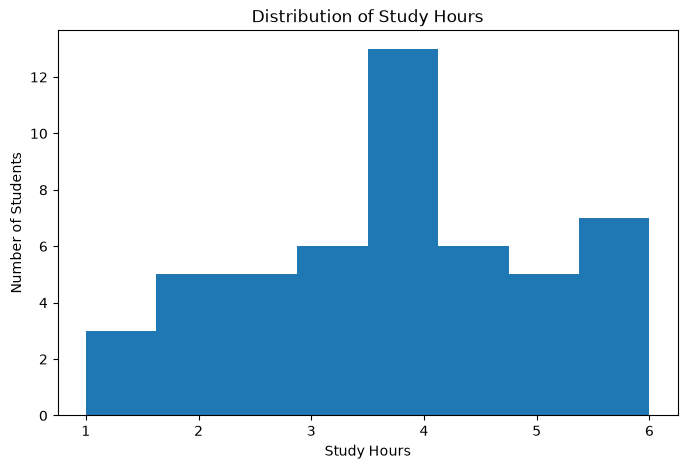

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["Study_Hours"], bins=8)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")

plt.show()

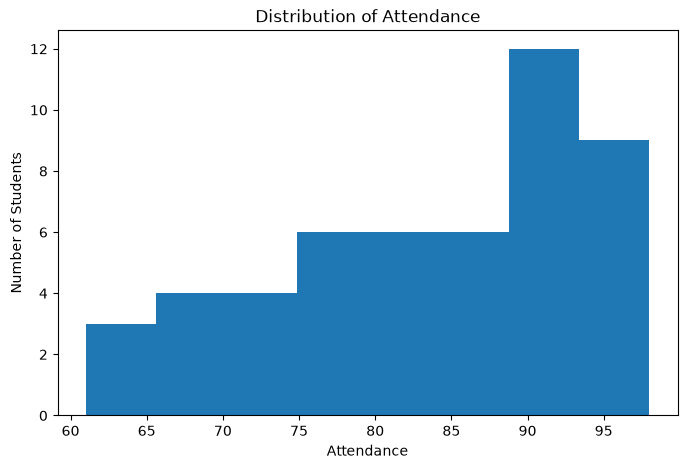

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(df["Attendance"], bins=8)

plt.title("Distribution of Attendance")
plt.xlabel("Attendance")
plt.ylabel("Number of Students")

plt.show()

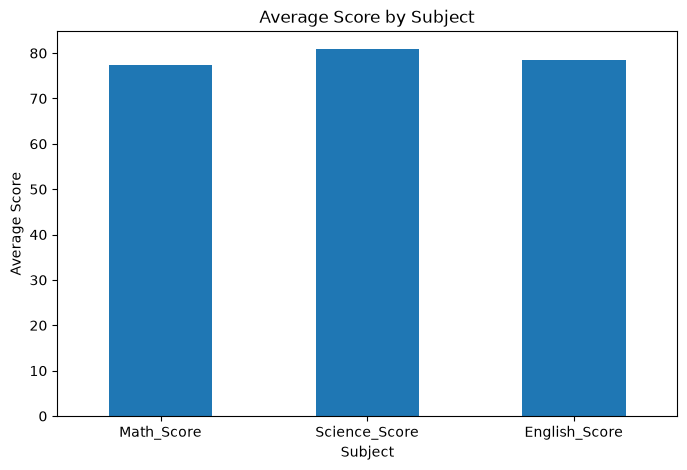

In [25]:
subject_means = df[
    ["Math_Score", "Science_Score", "English_Score"]
].mean()

plt.figure(figsize=(8, 5))

subject_means.plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.show()

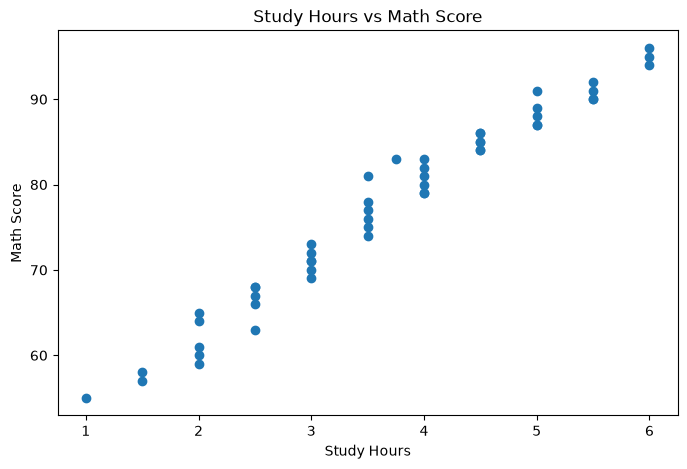

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Math_Score"])

plt.title("Study Hours vs Math Score")
plt.xlabel("Study Hours")
plt.ylabel("Math Score")

plt.show()

In [27]:
math_correlation = (
    df.corr(numeric_only=True)["Math_Score"]
    .abs()
    .sort_values(ascending=False)
)

print("Features most strongly related to Math Score:")
print(math_correlation)

Features most strongly related to Math Score:
Math_Score        1.000000
Attendance        0.991801
English_Score     0.987509
Study_Hours       0.983685
Science_Score     0.949687
Gender_Encoded    0.808353
Age               0.608389
Student_ID        0.005302
Name: Math_Score, dtype: float64


In [28]:
df.to_csv(
    "student_performance_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
